
[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


/var/folders/6j/g1bwknt9509bbgnr1xkxlr480000gn/T/ipykernel_93469/3726845715.py:11: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  table = pandas.read_csv(table_path, delimiter=',')


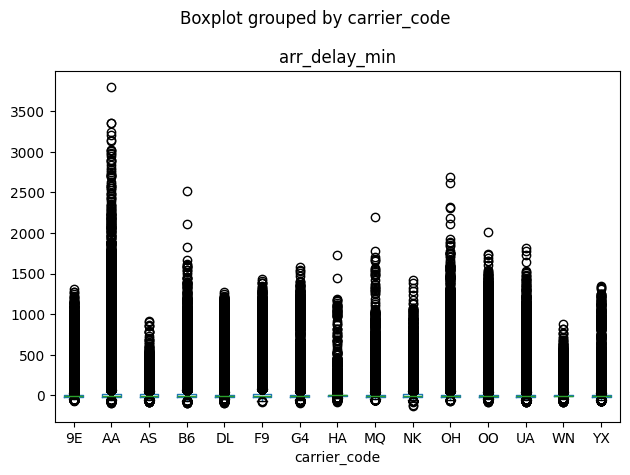

In [11]:
%pip install -q matplotlib

import os
import pandas
import matplotlib.pyplot as plt
%matplotlib inline

project_dir = os.getcwd()
table_path = os.path.join(project_dir, "flightData/flight_data_2024_renamed.csv")

table = pandas.read_csv(table_path, delimiter=',')
table.boxplot(by ='carrier_code', column =['arr_delay_min'], grid = False)
# table.boxplot(by ='day_of_week', column =['arr_delay_min'], grid = False)
# table.boxplot(by ='day_of_month', column =['arr_delay_min'], grid = False)
# table.boxplot(by ='origin_state', column =['arr_delay_min'], grid = False)

# table.boxplot(by ='carrier_code', column =['dep_delay_min'], grid = False)
# table.boxplot(by ='day_of_week', column =['dep_delay_min'], grid = False)
# table.boxplot(by ='day_of_month', column =['dep_delay_min'], grid = False)
# table.boxplot(by ='origin_state', column =['dep_delay_min'], grid = False)

plt.tight_layout()




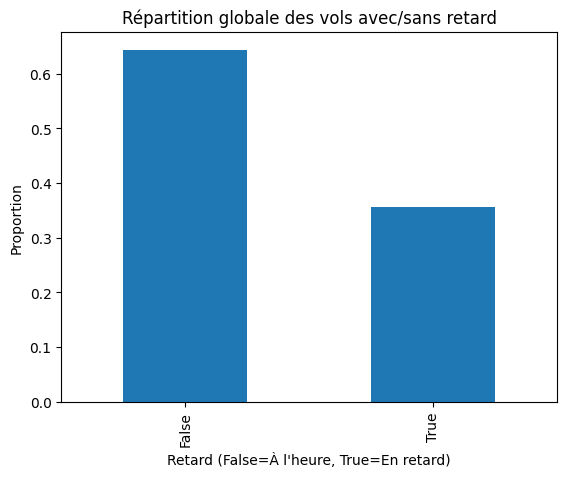

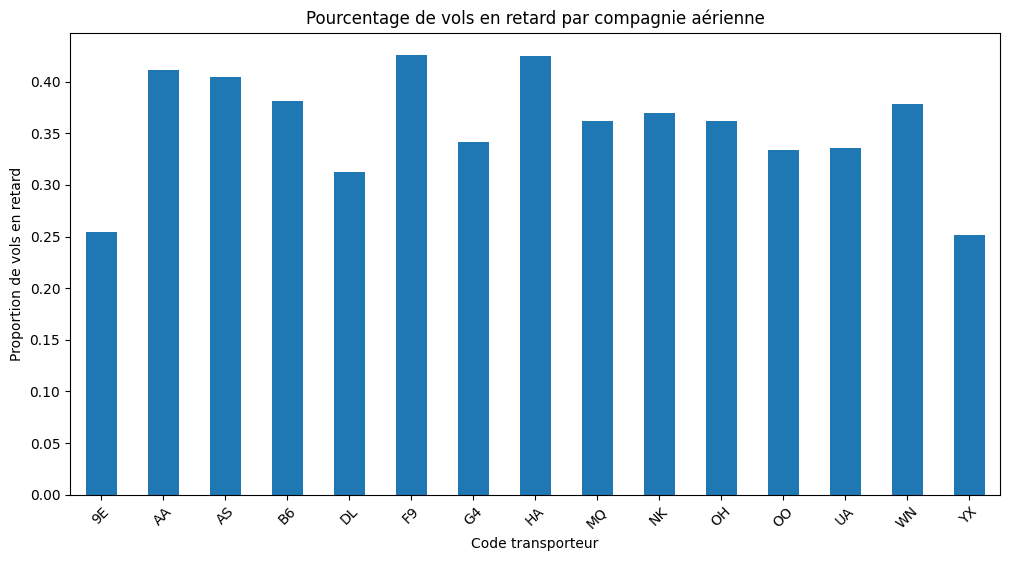

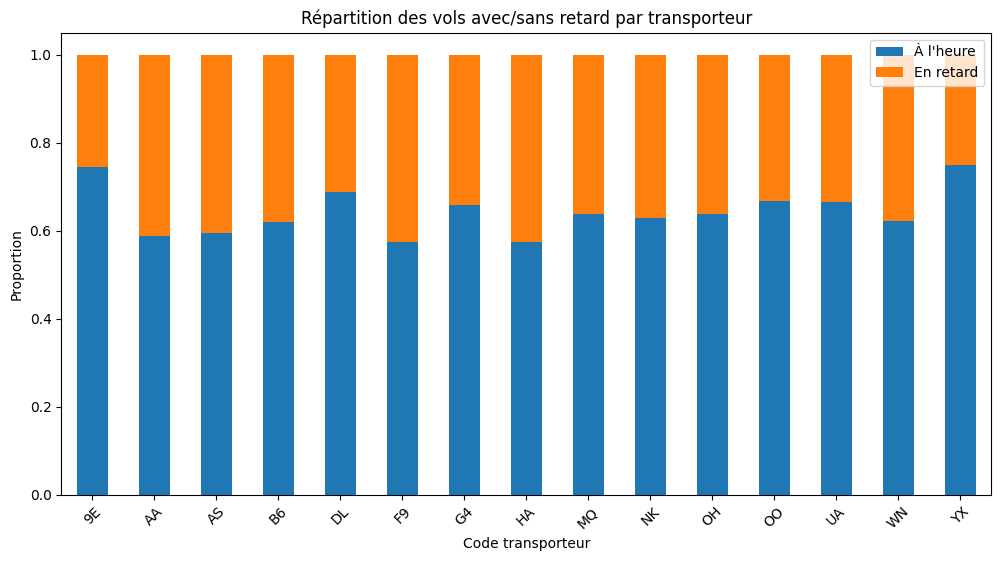

Statistiques de retard par transporteur:
Transporteur % Retard   Total vols  
-----------------------------------
9E           25.5       200094      
AA           41.1       984306      
9E           25.5       200094      
AA           41.1       984306      
AS           40.5       245819      
B6           38.1       240282      
AS           40.5       245819      
B6           38.1       240282      
DL           31.3       1009194     
F9           42.6       208624      
G4           34.1       117210      
DL           31.3       1009194     
F9           42.6       208624      
G4           34.1       117210      
HA           42.5       78530       
MQ           36.2       279955      
HA           42.5       78530       
MQ           36.2       279955      
NK           37.0       261103      
OH           36.2       227971      
NK           37.0       261103      
OH           36.2       227971      
OO           33.3       744658      
UA           33.6       760451     

In [12]:
# 1. Graphique général : Répartition globale des retards
barplot = table['is_late'].value_counts(normalize=True).plot.bar(grid=False)
plt.title('Répartition globale des vols avec/sans retard')
plt.ylabel('Proportion')
plt.xlabel('Retard (False=À l\'heure, True=En retard)')
plt.show()

# 2. Analyse par compagnie aérienne : Pourcentage de vols en retard par transporteur
carrier_delay_rate = table.groupby('carrier_code')['is_late'].mean()
carrier_delay_rate.plot.bar(grid=False, figsize=(12, 6))
plt.title('Pourcentage de vols en retard par compagnie aérienne')
plt.ylabel('Proportion de vols en retard')
plt.xlabel('Code transporteur')
plt.xticks(rotation=45)
plt.show()

# 3. Tableau croisé : Répartition détaillée par transporteur
cross_tab = pandas.crosstab(table['carrier_code'], table['is_late'], normalize='index')
cross_tab.plot.bar(stacked=True, grid=False, figsize=(12, 6))
plt.title('Répartition des vols avec/sans retard par transporteur')
plt.ylabel('Proportion')
plt.xlabel('Code transporteur')
plt.legend(['À l\'heure', 'En retard'])
plt.xticks(rotation=45)
plt.show()

# 4. Affichage des statistiques
print("Statistiques de retard par transporteur:")
print(f"{'Transporteur':<12} {'% Retard':<10} {'Total vols':<12}")
print("-" * 35)
for carrier in sorted(table['carrier_code'].unique()):
    carrier_data = table[table['carrier_code'] == carrier]
    pct_late = carrier_data['is_late'].mean() * 100
    total_flights = len(carrier_data)
    print(f"{carrier:<12} {pct_late:<10.1f} {total_flights:<12}")



Nombre de vols à visualiser (après filtrage): 6925166


/var/folders/6j/g1bwknt9509bbgnr1xkxlr480000gn/T/ipykernel_93469/1736830154.py:74: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


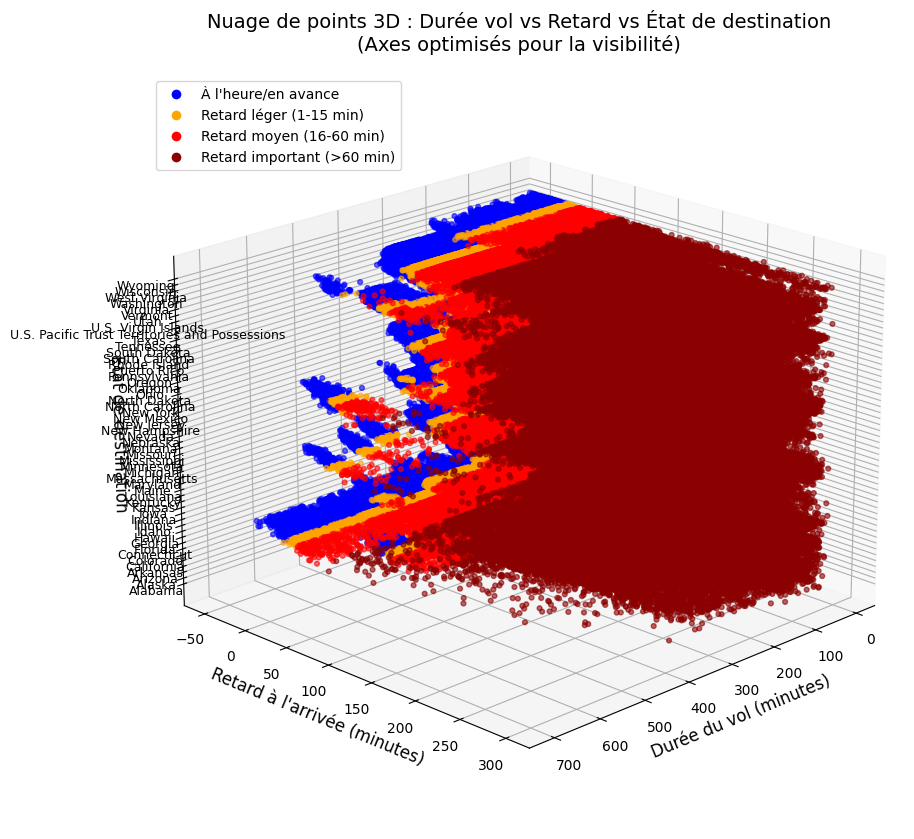


Répartition des vols par catégorie de retard:
À l'heure/en avance: 4437014 (64.1%)
Retard léger (1-15 min): 1118620 (16.2%)
Retard moyen (16-60 min): 900657 (13.0%)
Retard important (>60 min): 468875 (6.8%)

Corrélation durée vol vs retard: 0.012

Top 5 des états avec le plus de vols:
À l'heure/en avance: 4437014 (64.1%)
Retard léger (1-15 min): 1118620 (16.2%)
Retard moyen (16-60 min): 900657 (13.0%)
Retard important (>60 min): 468875 (6.8%)

Corrélation durée vol vs retard: 0.012

Top 5 des états avec le plus de vols:
Texas: 731487 vols (retard moyen: 6.3 min)
California: 729605 vols (retard moyen: 4.8 min)
Texas: 731487 vols (retard moyen: 6.3 min)
California: 729605 vols (retard moyen: 4.8 min)
Florida: 611364 vols (retard moyen: 6.8 min)
Illinois: 364937 vols (retard moyen: 4.0 min)
Florida: 611364 vols (retard moyen: 6.8 min)
Illinois: 364937 vols (retard moyen: 4.0 min)
Georgia: 361553 vols (retard moyen: 2.0 min)
Georgia: 361553 vols (retard moyen: 2.0 min)


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Créer le graphique 3D avec vos données de vol - AXES RÉORGANISÉS
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')

# Filtrer les données pour éviter les valeurs manquantes
data_clean = table.dropna(subset=['arr_delay_min', 'dest_state', 'air_time_min'])

# Filtrer les retards extrêmes pour une meilleure visibilité
data_clean = data_clean[data_clean['arr_delay_min'].between(-50, 300)]  # Éliminer les valeurs aberrantes
data_clean = data_clean[data_clean['air_time_min'] > 0]  # Éliminer les durées négatives

print(f"Nombre de vols à visualiser (après filtrage): {len(data_clean)}")

# NOUVELLE ORGANISATION DES AXES pour une meilleure visibilité:
# X : Durée du vol (air_time_min) - plus continu, meilleure répartition
# Y : Durée du retard (arr_delay_min) - permet de voir la concentration autour de 0
# Z : États (dest_state) - en hauteur pour séparer les groupes

# Convertir les états en valeurs numériques pour l'axe Z
states_unique = sorted(data_clean['dest_state'].unique())
state_to_num = {state: i for i, state in enumerate(states_unique)}
data_clean['dest_state_num'] = data_clean['dest_state'].map(state_to_num)

# Couleurs améliorées basées sur les retards
def get_color(delay):
    if delay <= 0:
        return 'blue'
    elif delay <= 15:
        return 'orange'
    elif delay <= 60:
        return 'red'
    else:
        return 'darkred'

colors = [get_color(delay) for delay in data_clean['arr_delay_min']]

# Créer le scatter plot 3D avec les nouveaux axes
scatter = ax.scatter(data_clean['air_time_min'],      # X: Durée du vol
                    data_clean['arr_delay_min'],      # Y: Retard
                    data_clean['dest_state_num'],     # Z: États (en hauteur)
                    c=colors, alpha=0.6, s=12)

# Configuration des axes - NOUVELLE DISPOSITION
ax.set_xlabel('Durée du vol (minutes)', fontsize=12)
ax.set_ylabel('Retard à l\'arrivée (minutes)', fontsize=12)
ax.set_zlabel('État de destination', fontsize=12)
ax.set_title('Nuage de points 3D : Durée vol vs Retard vs État de destination\n(Axes optimisés pour la visibilité)', fontsize=14)

# Configurer l'axe Z avec les noms d'états (seulement quelques-uns pour la lisibilité)
step = max(1, len(states_unique) // 1000)  # Afficher max 10 états
selected_indices = range(0, len(states_unique), step)
selected_states = [states_unique[i] for i in selected_indices]
ax.set_zticks(selected_indices)
ax.set_zticklabels(selected_states, fontsize=9)

# Améliorer l'angle de vue pour une meilleure perspective
ax.view_init(elev=20, azim=45)

# Légende améliorée avec plus de nuances
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='À l\'heure/en avance'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=8, label='Retard léger (1-15 min)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Retard moyen (16-60 min)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='darkred', markersize=8, label='Retard important (>60 min)')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.02, 0.98))

plt.tight_layout()
plt.show()

# Statistiques par catégorie de retard
print(f"\nRépartition des vols par catégorie de retard:")
on_time = len(data_clean[data_clean['arr_delay_min'] <= 0])
light_delay = len(data_clean[(data_clean['arr_delay_min'] > 0) & (data_clean['arr_delay_min'] <= 15)])
medium_delay = len(data_clean[(data_clean['arr_delay_min'] > 15) & (data_clean['arr_delay_min'] <= 60)])
heavy_delay = len(data_clean[data_clean['arr_delay_min'] > 60])

total = len(data_clean)
print(f"À l'heure/en avance: {on_time} ({on_time/total*100:.1f}%)")
print(f"Retard léger (1-15 min): {light_delay} ({light_delay/total*100:.1f}%)")
print(f"Retard moyen (16-60 min): {medium_delay} ({medium_delay/total*100:.1f}%)")
print(f"Retard important (>60 min): {heavy_delay} ({heavy_delay/total*100:.1f}%)")

# Afficher les corrélations
correlation_vol_retard = data_clean['air_time_min'].corr(data_clean['arr_delay_min'])
print(f"\nCorrélation durée vol vs retard: {correlation_vol_retard:.3f}")

print(f"\nTop 5 des états avec le plus de vols:")
state_counts = data_clean['dest_state'].value_counts().head()
for state, count in state_counts.items():
    avg_delay = data_clean[data_clean['dest_state'] == state]['arr_delay_min'].mean()
    print(f"{state}: {count} vols (retard moyen: {avg_delay:.1f} min)")